In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

In [2]:
def extract_coordinates_from_semantic_json(json_path: str) -> pd.DataFrame:
  """Parses a Google Timeline Semantic Location History JSON file and extracts

  latitude and longitude coordinates from 'visit -> topCandidate ->
  placeLocation'.

  Parameters:
  ----------
  json_path : str
      Path to the Google Timeline JSON file.

  Returns:
  -------
  pd.DataFrame
      Cleaned DataFrame containing 'latitude' and 'longitude' columns.
  """
  print(f"Loading Timeline dataset from: {json_path}...")

  with open(json_path, "r", encoding="utf-8") as file:
    raw_data = json.load(file)

  # Handle both direct list structures and nested 'timelineObjects' keys
  timeline_items = (
      raw_data
      if isinstance(raw_data, list)
      else raw_data.get("timelineObjects", raw_data)
  )

  extracted_points = []

  for item in timeline_items:
    # Retrieve nested location candidates
    visit_data = item.get("visit", {})
    top_candidate = visit_data.get("topCandidate", {})
    place_location = top_candidate.get("placeLocation", "")

    # Parse coordinates string formatted as "geo:latitude,longitude"
    if place_location.startswith("geo:"):
      try:
        clean_coords_str = place_location.replace("geo:", "")
        latitude_str, longitude_str = clean_coords_str.split(",")

        latitude_val = float(latitude_str)
        longitude_val = float(longitude_str)

        extracted_points.append((latitude_val, longitude_val))
      except (ValueError, AttributeError):
        # Skip malformed coordinate strings
        continue

  # Build Pandas DataFrame
  locations_df = pd.DataFrame(
      extracted_points, columns=["latitude", "longitude"]
  )

  # Filter out coordinates outside valid geographical boundaries
  valid_locations_df = locations_df[
      (locations_df["latitude"].between(-90, 90))
      & (locations_df["longitude"].between(-180, 180))
  ].copy()

  print(
      f"Successfully extracted {len(valid_locations_df)} valid location"
      " points."
  )
  return valid_locations_df

In [3]:
# Set your file path here
TIMELINE_JSON_PATH = "location-history.json"

# Extract location data
location_data_df = extract_coordinates_from_semantic_json(TIMELINE_JSON_PATH)

# Display the first few rows to verify extraction
location_data_df.head()

Loading Timeline dataset from: location-history.json...
Successfully extracted 16241 valid location points.


,latitude,longitude
0,4.659418,-74.108378
1,4.659418,-74.108378
2,4.654980,-74.055220
3,4.654391,-74.055318
4,4.725998,-74.057093


Filtering coordinates within the Americas bounding box...
Calculating 2D Kernel Density Estimation (KDE)... Please wait.
Rendering Heightmap texture for the Americas...


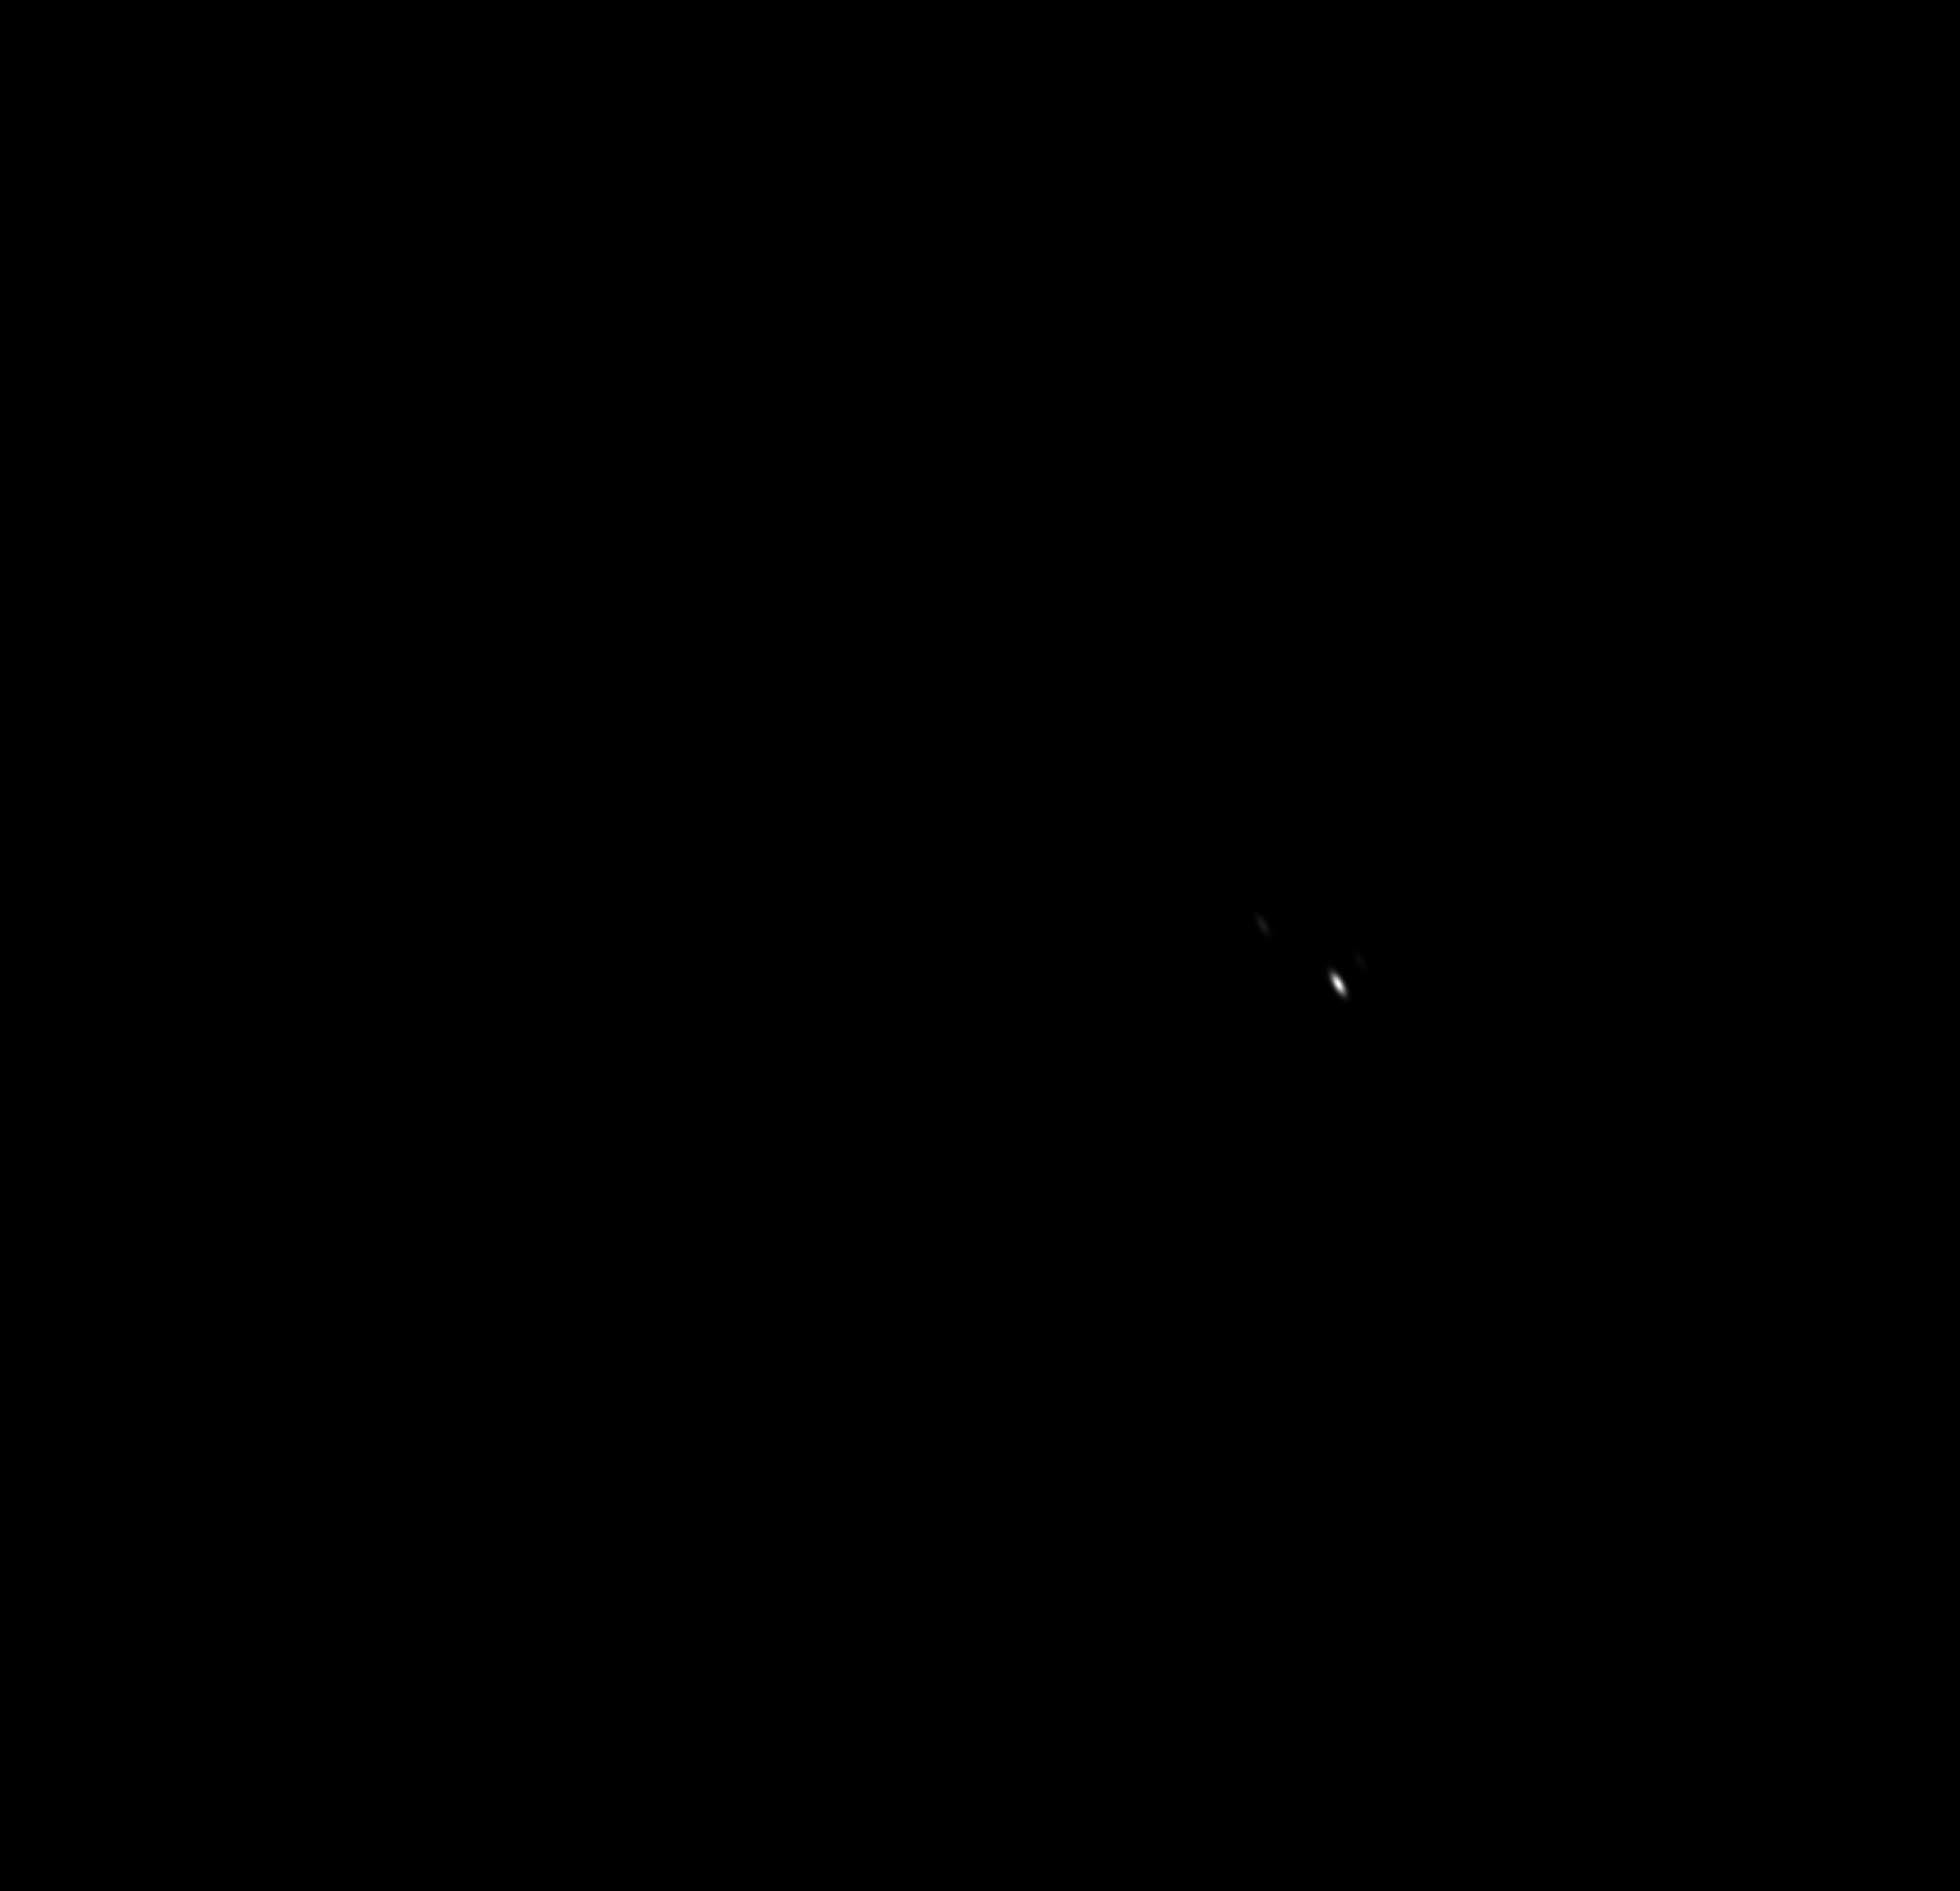

Americas Heightmap texture successfully saved at: heatmap_heightmap_americas.png


In [4]:
# Output file configuration
OUTPUT_IMAGE_PATH = "heatmap_heightmap_americas.png"
FIGURE_DPI = 300
GRID_RESOLUTION = 1200  # High-definition resolution for focused map

# Define geographic boundaries specifically for the Americas
MIN_LON, MAX_LON = -170.0, -30.0  # Longitude bounds (West to East)
MIN_LAT, MAX_LAT = -60.0, 75.0  # Latitude bounds (South to North)

print("Filtering coordinates within the Americas bounding box...")

# Filter DataFrame points strictly within the Americas bounding box
americas_mask = (
    location_data_df["longitude"].between(MIN_LON, MAX_LON)
) & (location_data_df["latitude"].between(MIN_LAT, MAX_LAT))
filtered_df = location_data_df[americas_mask].copy()

lon_data = filtered_df["longitude"].values
lat_data = filtered_df["latitude"].values

print("Calculating 2D Kernel Density Estimation (KDE)... Please wait.")

# Create grid specifically covering the Americas region
lon_grid = np.linspace(MIN_LON, MAX_LON, GRID_RESOLUTION)
# Maintain aspect ratio based on coordinate span
lat_span_ratio = (MAX_LAT - MIN_LAT) / (MAX_LON - MIN_LON)
lat_grid = np.linspace(
    MIN_LAT, MAX_LAT, int(GRID_RESOLUTION * lat_span_ratio)
)
mesh_lon, mesh_lat = np.meshgrid(lon_grid, lat_grid)

# Evaluate Gaussian KDE on filtered points
data_positions = np.vstack([lon_data, lat_data])
grid_positions = np.vstack([mesh_lon.ravel(), mesh_lat.ravel()])

kde = gaussian_kde(data_positions)
# Adjust peak sharpness (0.35 - 0.4 works great for regional focus)
kde.set_bandwidth(bw_method=kde.factor * 0.35)

density_z = kde(grid_positions).reshape(mesh_lon.shape)

# Normalize density strictly between 0.0 and 1.0
density_z_normalized = (density_z - density_z.min()) / (
    density_z.max() - density_z.min()
)

print("Rendering Heightmap texture for the Americas...")

# Compute figure aspect ratio dynamically
fig_width = 16.0
fig_height = fig_width * lat_span_ratio

fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=FIGURE_DPI)

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# Set exact axes limits
ax.set_xlim(MIN_LON, MAX_LON)
ax.set_ylim(MIN_LAT, MAX_LAT)

# Display density image mapped to Americas bounds
ax.imshow(
    density_z_normalized,
    cmap="gray",
    extent=[MIN_LON, MAX_LON, MIN_LAT, MAX_LAT],
    origin="lower",
    aspect="equal",
)

plt.axis("off")
plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

# Save focused Heightmap texture
plt.savefig(
    OUTPUT_IMAGE_PATH,
    bbox_inches="tight",
    pad_inches=0,
    facecolor="black",
    dpi=FIGURE_DPI,
)
plt.show()

print(
    f"Americas Heightmap texture successfully saved at: {OUTPUT_IMAGE_PATH}"
)

Loading world boundaries for Americas validation...


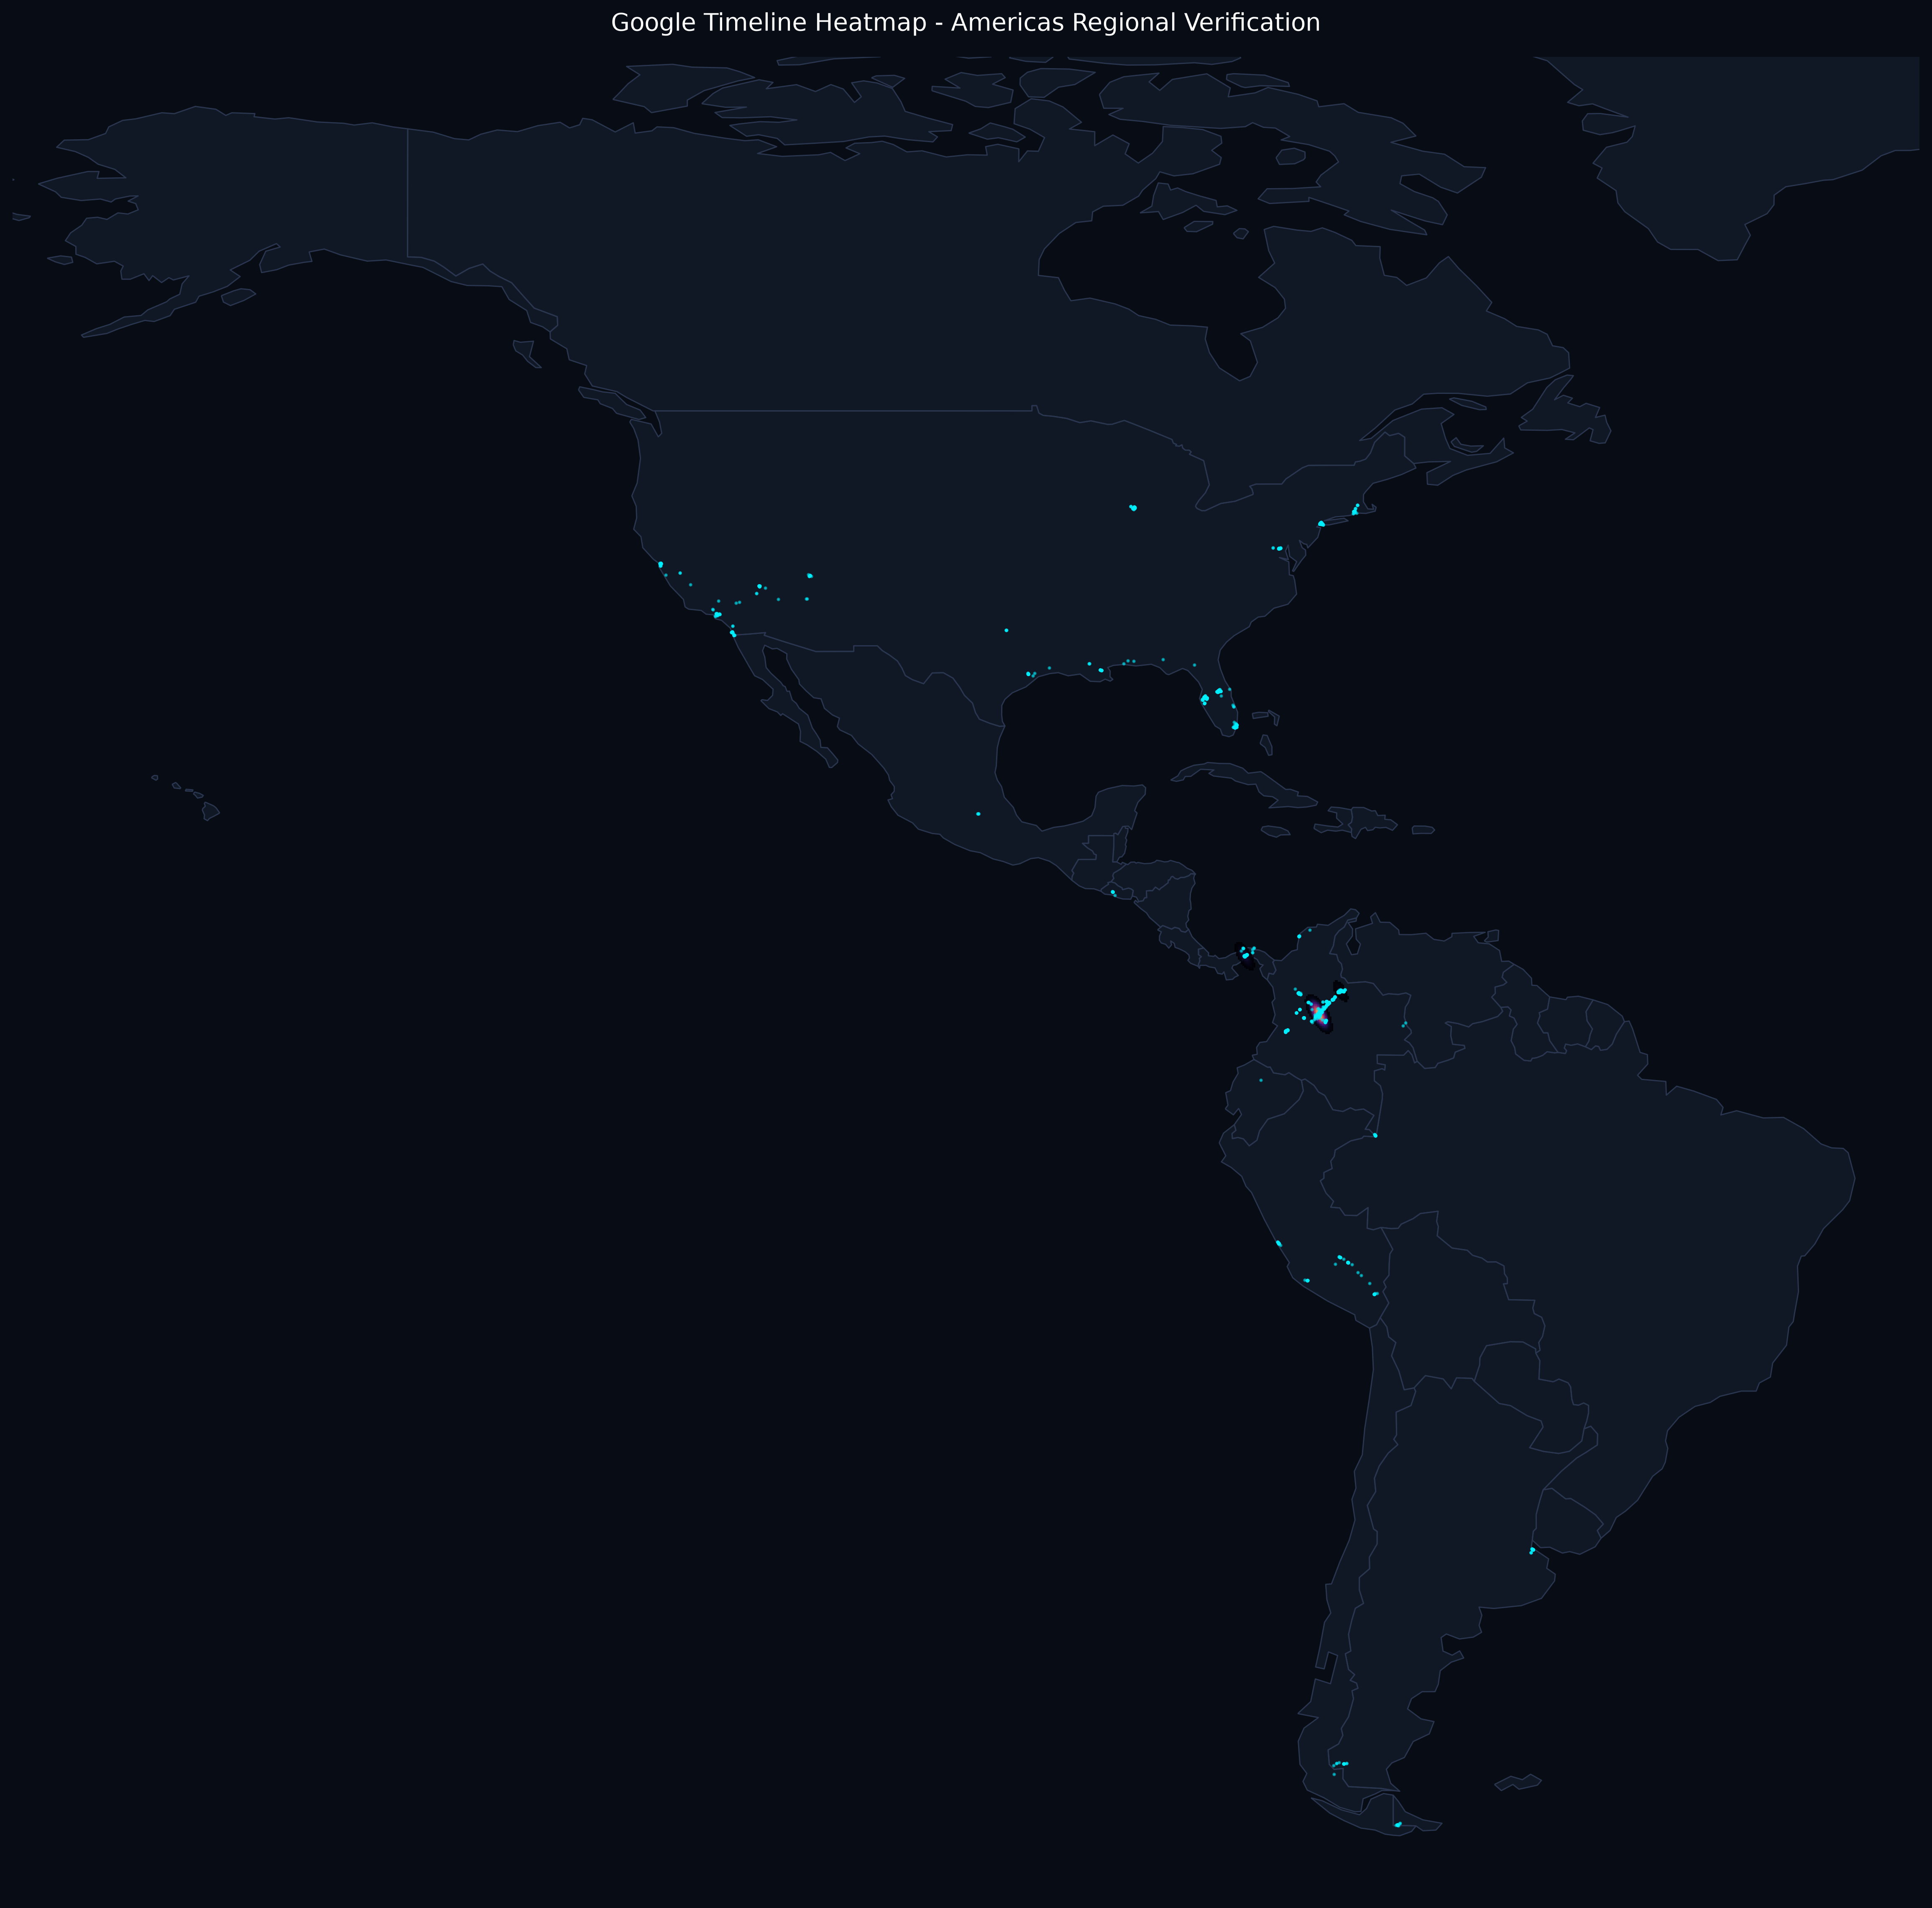

Americas validation overlay saved successfully at: heatmap_americas_reference.png


In [5]:
REFERENCE_IMAGE_PATH = "heatmap_americas_reference.png"
FIGURE_DPI = 300

print("Loading world boundaries for Americas validation...")
WORLD_URL = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(WORLD_URL)

# Compute canvas aspect ratio dynamically
lat_span_ratio = (MAX_LAT - MIN_LAT) / (MAX_LON - MIN_LON)
fig_width = 16.0
fig_height = fig_width * lat_span_ratio

fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=FIGURE_DPI)

fig.patch.set_facecolor("#080c14")
ax.set_facecolor("#080c14")

# Set boundaries restricted to the Americas
ax.set_xlim(MIN_LON, MAX_LON)
ax.set_ylim(MIN_LAT, MAX_LAT)

# 1. Plot Country Borders
world.boundary.plot(ax=ax, color="#2A364F", linewidth=0.7, zorder=1)
world.plot(ax=ax, color="#101826", zorder=0)

# 2. Overlay Heatmap
masked_density = np.ma.masked_where(
    density_z_normalized < 0.01, density_z_normalized
)

ax.imshow(
    masked_density,
    cmap="magma",
    extent=[MIN_LON, MAX_LON, MIN_LAT, MAX_LAT],
    origin="lower",
    aspect="equal",
    alpha=0.85,
    zorder=2,
)

# 3. Add Raw Data Points
ax.scatter(
    filtered_df["longitude"],
    filtered_df["latitude"],
    color="#00F0FF",
    s=1.0,
    alpha=0.5,
    zorder=3,
)

plt.title(
    "Google Timeline Heatmap - Americas Regional Verification",
    color="white",
    fontsize=14,
    pad=15,
)
plt.axis("off")
plt.subplots_adjust(top=0.95, bottom=0, right=1, left=0, hspace=0, wspace=0)

plt.savefig(
    REFERENCE_IMAGE_PATH,
    bbox_inches="tight",
    pad_inches=0.1,
    facecolor="#080c14",
    dpi=FIGURE_DPI,
)
plt.show()

print(
    f"Americas validation overlay saved successfully at:"
    f" {REFERENCE_IMAGE_PATH}"
)

In [6]:
# Identify unique cities visited (Americas only), keeping just the most
# recent visit per city. Uses offline reverse geocoding since most Timeline
# entries have no usable place name (just "Unknown"/"Home"/"Work"), then
# clusters nearby points (~25 km) into a single metro area so suburbs like
# "Egypt Lake-Leto" / "Gandy" collapse into "Tampa" instead of listing every
# small locality separately.
import reverse_geocoder as rg
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

# Reload the raw Timeline data since `timeline_items` is local to
# extract_coordinates_from_semantic_json() and isn't available here.
with open(TIMELINE_JSON_PATH, "r", encoding="utf-8") as file:
  raw_data = json.load(file)

timeline_items = (
    raw_data
    if isinstance(raw_data, list)
    else raw_data.get("timelineObjects", raw_data)
)

# Collect every visit's coordinates + timestamp within the Americas bbox
visit_records = []
for item in timeline_items:
  visit_data = item.get("visit", {})
  top_candidate = visit_data.get("topCandidate", {})
  place_location = top_candidate.get("placeLocation", "")
  start_time_str = item.get("startTime", "")

  if not place_location.startswith("geo:"):
    continue

  try:
    latitude_val, longitude_val = map(
        float, place_location.replace("geo:", "").split(",")
    )
  except (ValueError, AttributeError):
    continue

  # Restrict to the Americas geographic boundary (same bbox as the rest
  # of the notebook)
  if not (
      -170.0 <= longitude_val <= -30.0 and -60.0 <= latitude_val <= 75.0
  ):
    continue

  visit_records.append({
      "latitude": latitude_val,
      "longitude": longitude_val,
      "visit_time": pd.to_datetime(start_time_str, errors="coerce", utc=True),
  })

visits_df = pd.DataFrame(visit_records).dropna(subset=["visit_time"])
print(f"Collected {len(visits_df)} visit points within the Americas bbox.")

print("Reverse geocoding visit points to city names (offline lookup)...")
coordinates = list(zip(visits_df["latitude"], visits_df["longitude"]))
geocode_results = rg.search(coordinates)

visits_df["city"] = [result["name"] for result in geocode_results]
visits_df["state"] = [result["admin1"] for result in geocode_results]
visits_df["country"] = [result["cc"] for result in geocode_results]

# --- Cluster nearby visits into metro areas ---------------------------
# Group visit points within METRO_RADIUS_KM of each other so a city and
# its surrounding suburbs are treated as a single visited place.
METRO_RADIUS_KM = 25.0
EARTH_RADIUS_KM = 6371.0

lat_rad = np.radians(visits_df["latitude"].to_numpy())
lon_rad = np.radians(visits_df["longitude"].to_numpy())
unit_sphere_xyz = np.column_stack([
    np.cos(lat_rad) * np.cos(lon_rad),
    np.cos(lat_rad) * np.sin(lon_rad),
    np.sin(lat_rad),
])

# Convert the great-circle distance threshold into a straight-line
# (chord) distance on the unit sphere, since cKDTree works in Euclidean
# space.
chord_eps = 2 * np.sin((METRO_RADIUS_KM / EARTH_RADIUS_KM) / 2)

tree = cKDTree(unit_sphere_xyz)
close_pairs = tree.query_pairs(r=chord_eps, output_type="ndarray")

num_points = len(visits_df)
if len(close_pairs) > 0:
  row_idx = np.concatenate([close_pairs[:, 0], close_pairs[:, 1]])
  col_idx = np.concatenate([close_pairs[:, 1], close_pairs[:, 0]])
  adjacency = coo_matrix(
      (np.ones(len(row_idx)), (row_idx, col_idx)),
      shape=(num_points, num_points),
  )
  num_clusters, cluster_labels = connected_components(
      adjacency, directed=False
  )
else:
  num_clusters, cluster_labels = num_points, np.arange(num_points)

visits_df["metro_cluster"] = cluster_labels


def summarize_metro_cluster(group: pd.DataFrame) -> pd.Series:
  """Collapses a cluster of nearby visits into one representative city row."""
  # Label the cluster with its most-visited locality name
  most_visited_city = group["city"].mode().iloc[0]
  representative = group[group["city"] == most_visited_city].iloc[0]
  most_recent_visit = group.sort_values("visit_time", ascending=False).iloc[0]
  return pd.Series({
      "city": most_visited_city,
      "state": representative["state"],
      "country": representative["country"],
      "latitude": most_recent_visit["latitude"],
      "longitude": most_recent_visit["longitude"],
      "last_visit": most_recent_visit["visit_time"],
      "visit_count": len(group),
  })


visited_cities_df = (
    visits_df.groupby("metro_cluster")
    .apply(summarize_metro_cluster, include_groups=False)
    .reset_index(drop=True)
    .sort_values("last_visit", ascending=False)
    .reset_index(drop=True)
)

# Export to CSV for downstream use (e.g. Blender)
OUTPUT_CITIES_CSV_PATH = "visited_cities.csv"
visited_cities_df.to_csv(OUTPUT_CITIES_CSV_PATH, index=False)

print(
    f"✅ Identified {len(visited_cities_df)} visited cities/metro areas."
    f" Saved to {OUTPUT_CITIES_CSV_PATH}"
)
visited_cities_df.head(20)

Collected 16241 visit points within the Americas bbox.
Reverse geocoding visit points to city names (offline lookup)...
Loading formatted geocoded file...
✅ Identified 83 visited cities/metro areas. Saved to visited_cities.csv


,city,state,country,latitude,longitude,last_visit,visit_count
0,Cota,Cundinamarca,CO,4.742654,-74.056415,2026-08-12 17:29:48.267000+00:00,13063
1,Tampa,Florida,US,27.980365,-82.535403,2026-08-07 17:21:58.558000+00:00,108
2,Williamsburg,Florida,US,28.370568,-81.519359,2026-08-05 16:42:18+00:00,80
3,Chicago,Illinois,US,41.980259,-87.908986,2026-06-08 00:36:41.928000+00:00,63
4,Duitama,Boyaca,CO,5.807520,-73.032189,2026-05-03 13:36:06+00:00,51
5,El Cocuy,Boyaca,CO,6.333296,-72.683467,2026-05-03 10:40:04.718000+00:00,545
6,Panama,Panama,PA,9.067390,-79.386346,2025-12-21 17:14:13.019000+00:00,1520
7,Portobelo,Colon,PA,9.554062,-79.654662,2025-03-29 18:43:24.079000+00:00,4
8,Sabanitas,Colon,PA,9.340378,-79.804396,2025-03-29 12:50:07.821000+00:00,1
9,Canita,Panama,PA,9.223974,-78.966251,2025-03-23 12:03:14.890000+00:00,2
